In [ ]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 150)

In [ ]:
while not os.path.isdir(os.path.join(os.getcwd(), 'data')):
    os.chdir("../") # set cwd to root dir

In [4]:
lf_control_df_02 = pd.read_csv("data/DUO-GAIT/processed/OG_st_control/sub_02/left_foot_core_params.csv")
lf_control_df_02.rename({ "timestamps": "Time (secs)" }, axis=1, inplace=True)
lf_control_df_02['Setup'] = 'Control + LF'

rf_control_df_02 = pd.read_csv("data/DUO-GAIT/processed/OG_st_control/sub_02/right_foot_core_params.csv")
rf_control_df_02.rename({ "timestamps": "Time (secs)" }, axis=1, inplace=True)
rf_control_df_02['Setup'] = 'Control + RF'

lf_fatigue_df_02 = pd.read_csv("data/DUO-GAIT/processed/OG_st_fatigue/sub_02/left_foot_core_params.csv")
lf_fatigue_df_02.rename({ "timestamps": "Time (secs)" }, axis=1, inplace=True)
lf_fatigue_df_02['Setup'] = 'Fatigue + LF'

rf_fatigue_df_02 = pd.read_csv("data/DUO-GAIT/processed/OG_st_fatigue/sub_02/right_foot_core_params.csv")
rf_fatigue_df_02.rename({ "timestamps": "Time (secs)" }, axis=1, inplace=True)
rf_fatigue_df_02['Setup'] = 'Fatigue + RF'

foot_df_02 = pd.concat([lf_control_df_02, rf_control_df_02, lf_fatigue_df_02, rf_fatigue_df_02], axis=0)
foot_df_02

,stride_index,Time (secs),stride_lengths,clearances_min,clearances_max,stride_times,swing_times,stance_times,stance_ratios,fo_times,ic_times,fo_samples,ic_samples,is_outlier,turning_step,turning_interval,interrupted,Setup
0,0,2.80469,1.492164,0.004280,0.062994,1.10937,0.47656,0.63281,0.570423,3.43750,3.91406,440,501,False,False,True,False,Control + LF
1,1,3.91406,1.586318,0.002565,0.062007,1.09375,0.48437,0.60938,0.557147,4.52344,5.00781,579,641,False,False,True,False,Control + LF
2,2,5.00781,1.713094,0.028664,0.077349,1.07813,0.49219,0.58594,0.543478,5.59375,6.08594,716,779,False,False,False,False,Control + LF
3,3,6.08594,1.682749,0.001061,0.062864,1.07812,0.48437,0.59375,0.550727,6.67969,7.16406,855,917,False,False,False,False,Control + LF
4,4,7.16406,1.667110,0.014086,0.074089,1.07813,0.49219,0.58594,0.543478,7.75000,8.24219,992,1055,False,False,False,False,Control + LF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,327,370.25000,1.541911,0.014123,0.064523,1.08594,0.49219,0.59375,0.546761,370.84375,371.33594,47468,47531,False,False,False,False,Fatigue + RF
328,328,371.33594,1.535646,0.022723,0.069562,1.04688,0.46094,0.58594,0.559701,371.92188,372.38282,47606,47665,False,False,False,False,Fatigue + RF
329,329,372.38282,1.511071,0.009347,0.063607,1.07031,0.46094,0.60937,0.569340,372.99219,373.45313,47743,47802,False,False,False,False,Fatigue + RF
330,330,373.45313,1.676061,0.017923,0.066817,1.07812,0.47656,0.60156,0.557971,374.05469,374.53125,47879,47940,False,False,True,False,Fatigue + RF


**Filter out outlier strides**

In [5]:
lf_control_df_02 = lf_control_df_02[lf_control_df_02['is_outlier']==False]
rf_control_df_02 = rf_control_df_02[rf_control_df_02['is_outlier']==False]
lf_fatigue_df_02 = lf_fatigue_df_02[lf_fatigue_df_02['is_outlier']==False]
rf_fatigue_df_02 = rf_fatigue_df_02[rf_fatigue_df_02['is_outlier']==False]
foot_df_02 = foot_df_02[foot_df_02['is_outlier']==False]

**Samples for left foot during control walk**

In [6]:
print(lf_control_df_02['Time (secs)'].max(), "secs of walking session")
print(len(lf_control_df_02), "non outlier strides")
print(lf_control_df_02['ic_samples'].max(), "samples collected by IMU sensors (128 Hz)")

370.875 secs of walking session
305 non outlier strides
47609 samples collected by IMU sensors (128 Hz)


**Samples for left foot during fatigue walk**

In [7]:
print(lf_fatigue_df_02['Time (secs)'].max(), "secs of walking session")
print(len(lf_fatigue_df_02), "non outlier strides")
print(lf_fatigue_df_02['ic_samples'].max(), "samples collected by IMU sensors (128 Hz)")

374.0156299999999 secs of walking session
310 non outlier strides
48010 samples collected by IMU sensors (128 Hz)


**Visualize gait parameters for 2nd participant**

<Axes: xlabel='stride_times'>

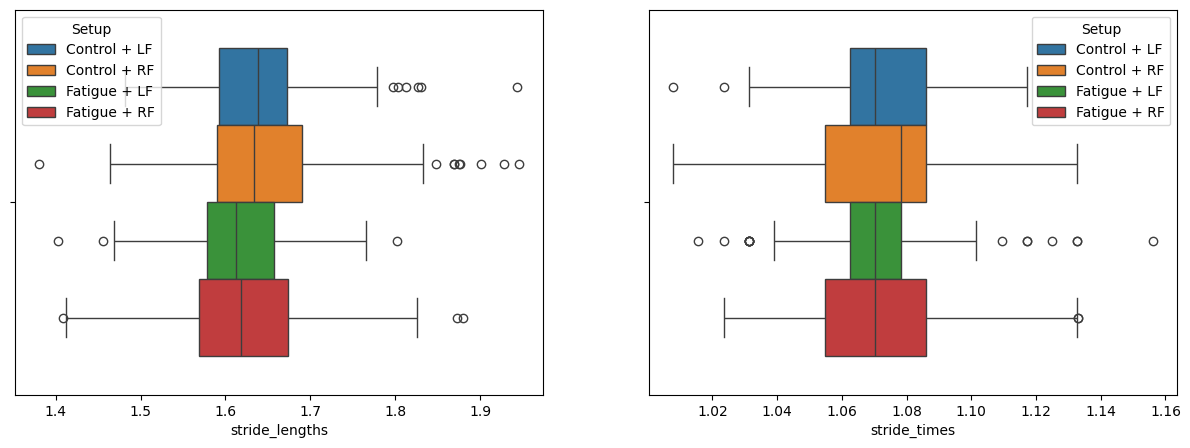

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(foot_df_02, x="stride_lengths", hue='Setup', ax=axes[0])
sns.boxplot(foot_df_02, x="stride_times", hue='Setup', ax=axes[1])

You have less stride length on average when fatigued. For stride time, it takes much longer to complete it during control. 

<Axes: xlabel='stance_times'>

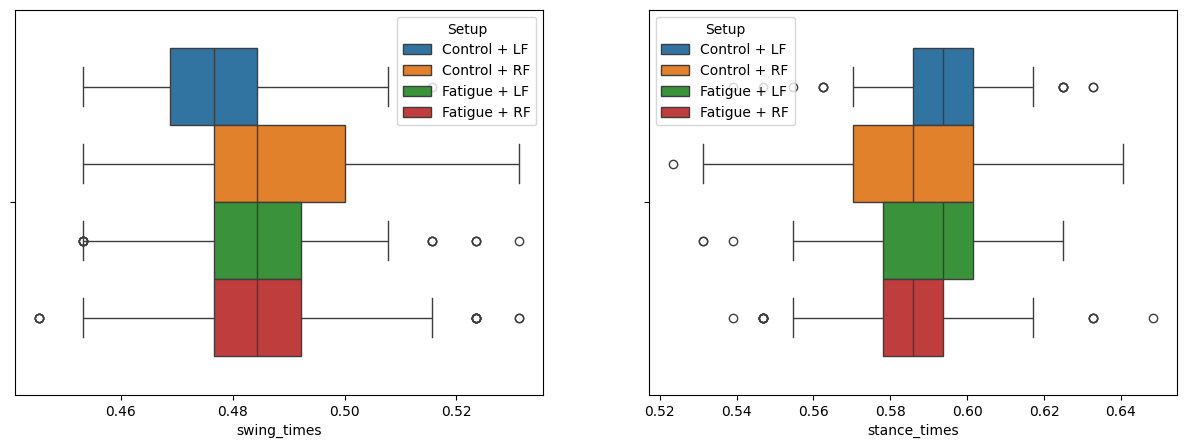

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(foot_df_02, x="swing_times", hue='Setup', ax=axes[0])
sns.boxplot(foot_df_02, x="stance_times", hue='Setup', ax=axes[1])

Swing time is much less for this person using the left foot during normal walk. Stance times are longer for left foot compared to right foot. This indicates a left foot dominance.

<Axes: xlabel='stance_ratios'>

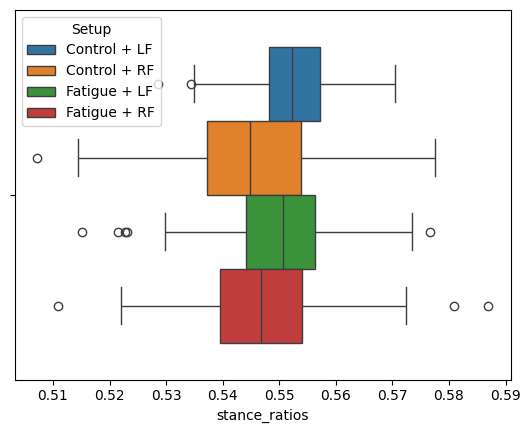

In [10]:
sns.boxplot(foot_df_02, x="stance_ratios", hue='Setup')

Another clear indication of left foot dominance. Body is mostly supported by left foot due having higher average ratio. 

<Axes: xlabel='clearances_max'>

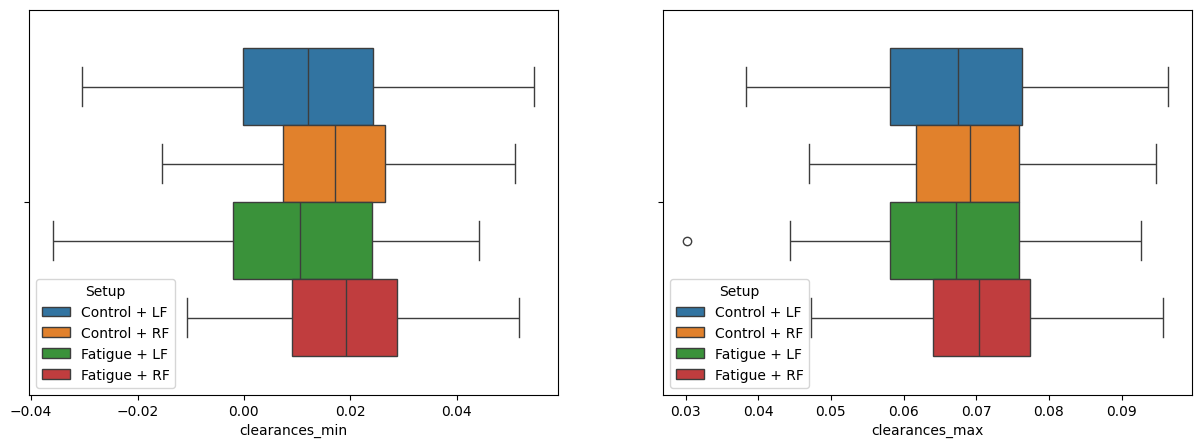

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(foot_df_02, x="clearances_min", hue='Setup', ax=axes[0])
sns.boxplot(foot_df_02, x="clearances_max", hue='Setup', ax=axes[1])

Left foot has lower clearance on average during mid swing compared to right foot. 

In [12]:
num_participants = 18

In [13]:
foot_df = pd.DataFrame()

for i in range(0, num_participants):
    pid = i+1

    if not os.path.exists(f"data/DUO-GAIT/processed/OG_st_control/sub_{pid:02}/left_foot_core_params.csv") or not f"data/DUO-GAIT/processed/OG_st_control/sub_{pid:02}/right_foot_core_params.csv" or not f"data/DUO-GAIT/processed/OG_st_fatigue/sub_{pid:02}/left_foot_core_params.csv" or not f"data/DUO-GAIT/processed/OG_st_fatigue/sub_{pid:02}/right_foot_core_params.csv":
        continue

    lf_control_df = pd.read_csv(f"data/DUO-GAIT/processed/OG_st_control/sub_{pid:02}/left_foot_core_params.csv")
    lf_control_df.rename({ "timestamps": "Time (secs)" }, axis=1, inplace=True)
    lf_control_df['Setup'] = 'Control + LF'
    lf_control_df['Participant'] = pid

    rf_control_df = pd.read_csv(f"data/DUO-GAIT/processed/OG_st_control/sub_{pid:02}/right_foot_core_params.csv")
    rf_control_df.rename({ "timestamps": "Time (secs)" }, axis=1, inplace=True)
    rf_control_df['Setup'] = 'Control + RF'
    rf_control_df['Participant'] = pid

    lf_fatigue_df = pd.read_csv(f"data/DUO-GAIT/processed/OG_st_fatigue/sub_{pid:02}/left_foot_core_params.csv")
    lf_fatigue_df.rename({ "timestamps": "Time (secs)" }, axis=1, inplace=True)
    lf_fatigue_df['Setup'] = 'Fatigue + LF'
    lf_fatigue_df['Participant'] = pid

    rf_fatigue_df = pd.read_csv(f"data/DUO-GAIT/processed/OG_st_fatigue/sub_{pid:02}/right_foot_core_params.csv")
    rf_fatigue_df.rename({ "timestamps": "Time (secs)" }, axis=1, inplace=True)
    rf_fatigue_df['Setup'] = 'Fatigue + RF'
    rf_fatigue_df['Participant'] = pid

    foot_df = pd.concat([foot_df, lf_control_df, rf_control_df, lf_fatigue_df, rf_fatigue_df], axis=0)

foot_df = foot_df[foot_df['is_outlier']==False]
foot_df

,stride_index,Time (secs),stride_lengths,clearances_min,clearances_max,stride_times,swing_times,stance_times,stance_ratios,fo_times,ic_times,fo_samples,ic_samples,is_outlier,turning_step,turning_interval,interrupted,Setup,Participant
0,0,5.02344,1.516293,0.009107,0.079038,1.18750,0.51563,0.67187,0.565785,5.69531,6.21094,729,795,False,False,True,False,Control + LF,1
1,1,6.21094,1.407251,0.016140,0.077253,1.17968,0.49218,0.68750,0.582785,6.89844,7.39062,883,946,False,False,True,False,Control + LF,1
2,2,7.39062,1.519046,0.015995,0.077782,1.15626,0.49219,0.66407,0.574326,8.05469,8.54688,1031,1094,False,False,False,False,Control + LF,1
3,3,8.54688,1.519612,0.012495,0.080218,1.17187,0.51563,0.65624,0.559994,9.20312,9.71875,1178,1244,False,False,False,False,Control + LF,1
4,4,9.71875,1.422920,0.009775,0.076342,1.09375,0.48438,0.60937,0.557138,10.32812,10.81250,1322,1384,False,False,False,False,Control + LF,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334,334,375.99219,1.175752,-0.005002,0.055427,1.12500,0.49219,0.63281,0.562498,376.62500,377.11719,48208,48271,False,False,False,False,Fatigue + RF,18
335,335,377.11719,1.243635,-0.001630,0.055835,1.13281,0.49219,0.64062,0.565514,377.75781,378.25000,48353,48416,False,False,False,False,Fatigue + RF,18
336,336,378.25000,1.234334,-0.008496,0.053434,1.14063,0.49219,0.64844,0.568493,378.89844,379.39063,48499,48562,False,False,False,False,Fatigue + RF,18
337,337,379.39063,1.133531,-0.000762,0.055047,1.13281,0.48438,0.64843,0.572408,380.03906,380.52344,48645,48707,False,False,True,False,Fatigue + RF,18


<Axes: xlabel='Participant', ylabel='count'>

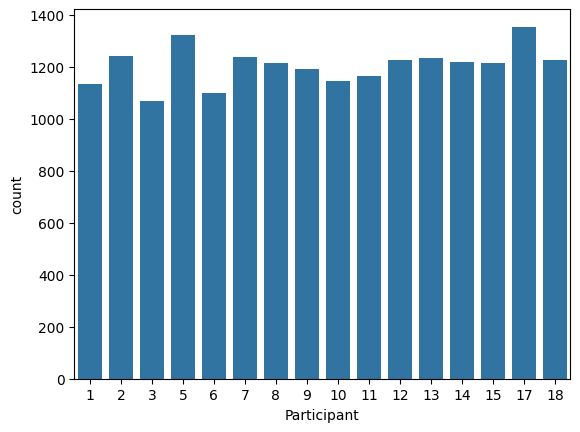

In [14]:
sns.countplot(foot_df, x='Participant')

2 participants are missing

**Visualize same distributions for all participants**

<Axes: xlabel='stride_times'>

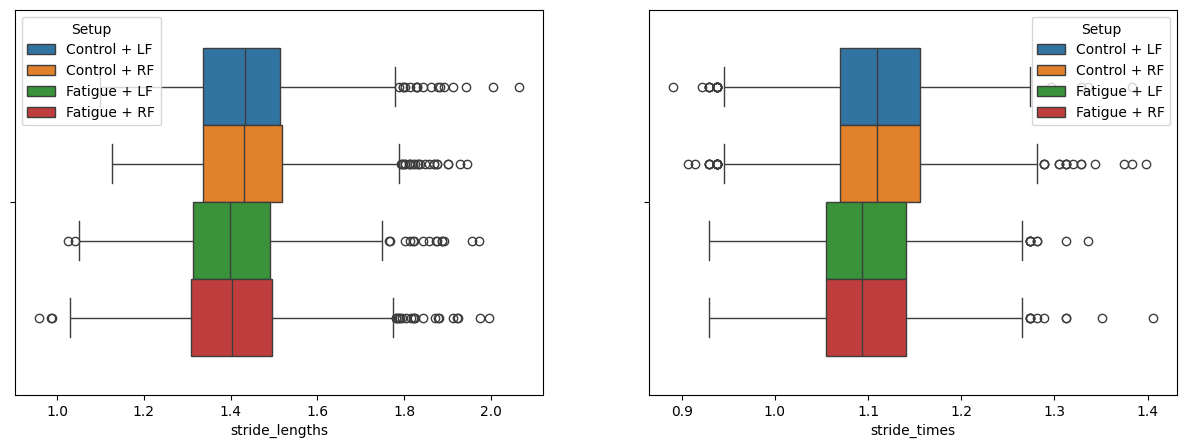

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(foot_df, x="stride_lengths", hue='Setup', ax=axes[0])
sns.boxplot(foot_df, x="stride_times", hue='Setup', ax=axes[1])

Looking at all of the participants, it seems that even stride times are shorter when fatigued. 

<Axes: xlabel='stance_times'>

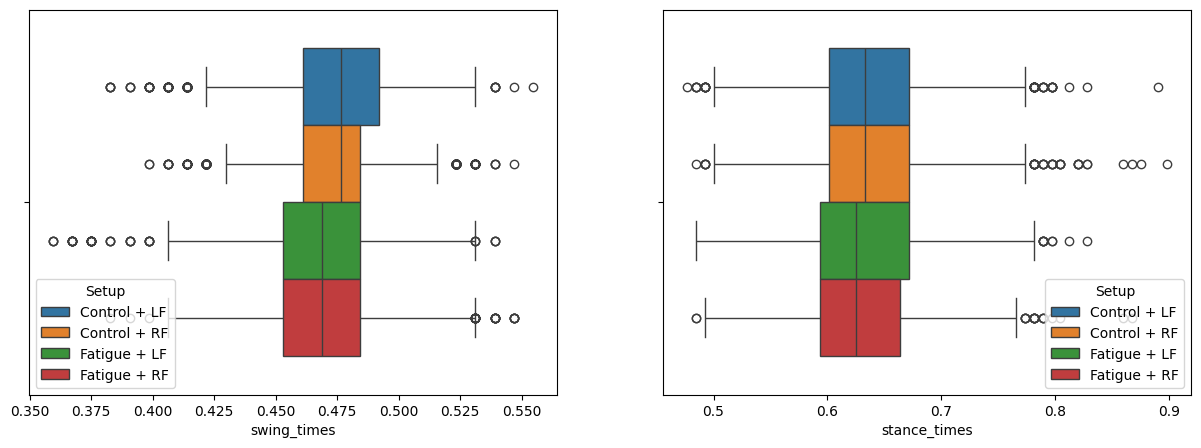

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(foot_df, x="swing_times", hue='Setup', ax=axes[0])
sns.boxplot(foot_df, x="stance_times", hue='Setup', ax=axes[1])

Swing and stance times are shorter during fatigue walk.

<Axes: xlabel='stance_ratios'>

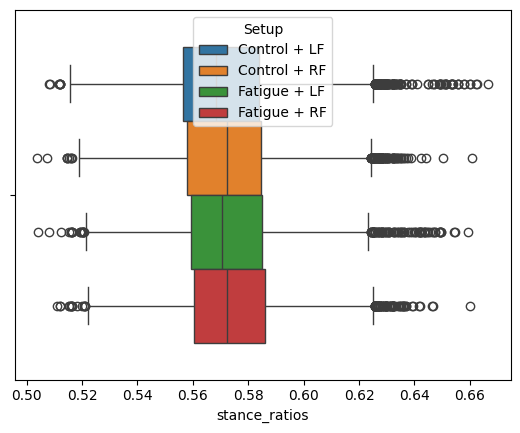

In [17]:
sns.boxplot(foot_df, x="stance_ratios", hue='Setup')

<Axes: xlabel='clearances_max'>

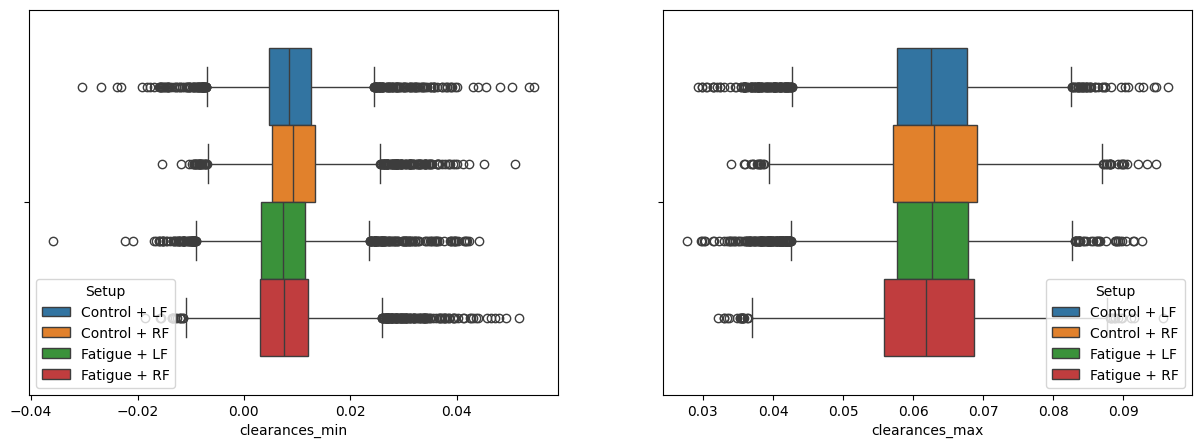

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(foot_df, x="clearances_min", hue='Setup', ax=axes[0])
sns.boxplot(foot_df, x="clearances_max", hue='Setup', ax=axes[1])